### Libaries

In [36]:
pip install pandas numpy nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd

qa = pd.read_csv("data/medquad.csv")
qa.head()

,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


### EDA

In [38]:
qa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16412 entries, 0 to 16411
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   question    16412 non-null  object
 1   answer      16407 non-null  object
 2   source      16412 non-null  object
 3   focus_area  16398 non-null  object
dtypes: object(4)
memory usage: 513.0+ KB


In [39]:
qa.columns

Index(['question', 'answer', 'source', 'focus_area'], dtype='object')

In [40]:
# --- Step 1: Handling Missing Values ---
# Removing rows where 'answer' or 'focus_area' is missing
qa.dropna(subset=['answer', 'focus_area'], inplace=True)



In [41]:
qa.dropna(inplace=True)
qa.drop_duplicates(inplace=True)

In [46]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

qa["clean_question"] = qa["question"].apply(clean_text)
qa["clean_answer"] = qa["answer"].apply(clean_text)

In [48]:
import nltk
from nltk.tokenize import word_tokenize

# Download the necessary shredding files
nltk.download('punkt')

# Applying segmentation to the question and answer
qa['question_tokens'] = qa['clean_question'].apply(word_tokenize)
qa['answer_tokens'] = qa['clean_answer'].apply(word_tokenize)

print("Tokenization completed!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenization completed!


In [49]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

qa['question_no_stop'] = qa['question_tokens'].apply(remove_stopwords)
qa['answer_no_stop'] = qa['answer_tokens'].apply(remove_stopwords)

print("Stopwords removed!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stopwords removed!


In [50]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

qa['final_question'] = qa['question_no_stop'].apply(lemmatize_tokens)
qa['final_answer'] = qa['answer_no_stop'].apply(lemmatize_tokens)

#  Convert words to a clean sentence for storage
qa['processed_question_text'] = qa['final_question'].apply(lambda x: " ".join(x))
qa['processed_answer_text'] = qa['final_answer'].apply(lambda x: " ".join(x))

print("Lemmatization completed! Your pipeline is now full.")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Lemmatization completed! Your pipeline is now full.


In [51]:
# display the difference
display(qa[['question', 'processed_question_text']].head())

,question,processed_question_text
0,What is (are) Glaucoma ?,glaucoma
1,What causes Glaucoma ?,cause glaucoma
2,What are the symptoms of Glaucoma ?,symptom glaucoma
3,What are the treatments for Glaucoma ?,treatment glaucoma
4,What is (are) Glaucoma ?,glaucoma


In [52]:
# --- Step 3: Exploratory Data Analysis (Quick Check) ---
# See how many questions we have per focus area
focus_counts = qa['focus_area'].value_counts().head(10)
print("Top 10 Medical Focus Areas:")
print(focus_counts)

Top 10 Medical Focus Areas:
focus_area
Breast Cancer             53
Prostate Cancer           43
Stroke                    35
Skin Cancer               34
Alzheimer's Disease       30
Colorectal Cancer         29
Lung Cancer               29
Heart Failure             28
High Blood Cholesterol    28
Heart Attack              28
Name: count, dtype: int64


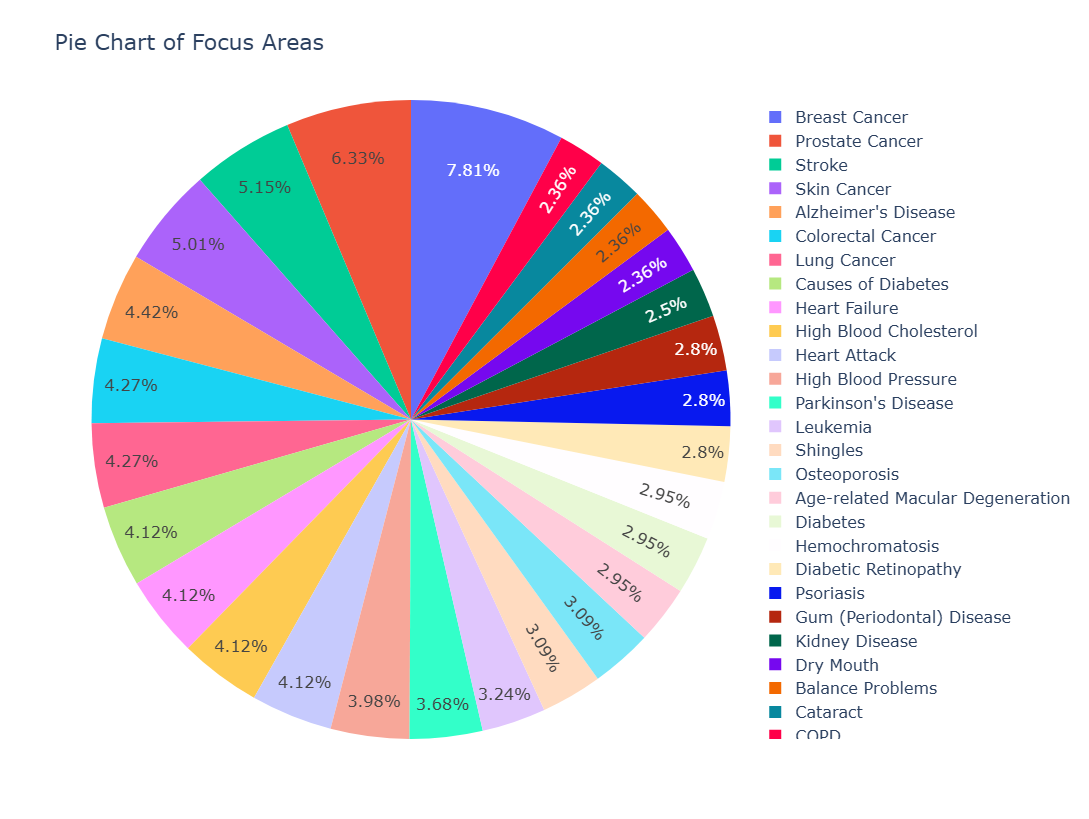

In [53]:
import pandas as pd
import plotly.graph_objects as go

value_counts = df['focus_area'].value_counts()
result = value_counts[value_counts > 15]

fig = go.Figure(data=[go.Pie(labels=result.index, values=result.values)])
fig.update_layout(title='Pie Chart of Focus Areas', width=1200, height=800, font=dict(size=16))
fig.show()

### spliting Data Q&A

In [54]:
from sklearn.model_selection import train_test_split

# --- Step 5: Split the QA Data ---
# We split the cleaned columns into 80% train and 20% test
qa_train, qa_test = train_test_split(qa, test_size=0.2, random_state=42)

print(f"Training set size: {len(qa_train)}")
print(f"Testing set size: {len(qa_test)}")

Training set size: 13076
Testing set size: 3269


### Convert to GPT form

In [55]:
def format_qa(row):
    return f"Patient: {row['clean_question']} \nDoctor: {row['clean_answer']}"

qa["gpt_input"] = qa.apply(format_qa, axis=1)

### Save cleaned Q&A Data

In [56]:
qa[["gpt_input"]].to_csv("cleaned_data/qa_gpt.csv", index=False)

### TEST

In [57]:
import random


# ANSI color codes

color_codes = {

    "blue": 34,
    "green": 32,
    "red": 31,
    "purple": 35,
    "orange": 33,
    "yellow": 33,
    "pink": 35,
    "brown": 33,
    "gray": 37
}



for i in range(0, len(df), 7):

    color = random.choice(list(color_codes.values()))

    print(f"\033[1;{color}mThe question is: {df['question'][i]}\033[0m\n\033[1;{color}m The answer is: {df['answer'][i]}\033[0m\n")

    if i > 30:

        break

The question is: What is (are) Glaucoma ?
 The answer is: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops  There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye there is a small space called the anterior chamber. A clear fluid flows through this chamber and bathes and nourishes the nearby tissues. (Watch the video to learn more about glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) In glaucoma, for still unknown reasons, the fluid drains too slowly out of the eye. As the fluid builds up, the pressure inside the eye rises. Unless this pressure is controlled, it may cause damage to the optic nerve and other parts of the eye and result in loss of visio

### Text Cleaning

In [58]:
import re
import string

def clean_qa_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove specific noise phrases found in your test (videos, graphics, etc.)
    noise_phrases = [
        r"watch the video to learn more",
        r"see this graphic for a quick overview",
        r"click the table on the right",
        r"see a glossary of glaucoma terms",
        r"to enlarge the video.*keyboard"
    ]
    for phrase in noise_phrases:
        text = re.sub(phrase, "", text)

    # 3. Remove punctuation and special characters
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    
    # 4. Remove extra whitespaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the enhanced cleaning to your QA dataframe
qa['cleaned_question'] = qa['question'].apply(clean_qa_text)
qa['cleaned_answer'] = qa['answer'].apply(clean_qa_text)

# Check one sample after cleaning
print("Cleaned Answer Sample:")
print(qa['cleaned_answer'].iloc[0])

Cleaned Answer Sample:
glaucoma is a group of diseases that can damage the eye s optic nerve and result in vision loss and blindness while glaucoma can strike anyone the risk is much greater for people over 60 how glaucoma develops there are several different types of glaucoma most of these involve the drainage system within the eye at the front of the eye there is a small space called the anterior chamber a clear fluid flows through this chamber and bathes and nourishes the nearby tissues about glaucoma in glaucoma for still unknown reasons the fluid drains too slowly out of the eye as the fluid builds up the pressure inside the eye rises unless this pressure is controlled it may cause damage to the optic nerve and other parts of the eye and result in loss of vision open angle glaucoma the most common type of glaucoma is called open angle glaucoma in the normal eye the clear fluid leaves the anterior chamber at the open angle where the cornea and iris meet when fluid reaches the angle